# AIM · 5주차 자율 과제
## VAE ① 잠재변수로 이미지 생성하기

**대상:** Python·PyTorch 기초 이수자 / **권장:** Google Colab Python 3, GPU 선택 가능.

로그, 평균과 분산, 정규분포를 짧게 복습한다. MNIST 픽셀은 0~1 범위로 유지한다. 이미지 분류에서 사용한 [-1,1] Normalize를 그대로 적용하지 않는다.

### 학습 목표
- AE와 VAE의 차이를 확률 분포 관점에서 설명한다.
- 재매개화와 ELBO 손실을 올바르게 구현한다.
- MNIST 재구성·prior 샘플·잠재 보간을 구분한다.

### 실행 방법
1. Colab에서 `파일 → 노트북 업로드`로 이 파일을 엽니다.
2. GPU를 사용할 경우 `런타임 → 런타임 유형 변경`에서 GPU를 선택합니다.
3. 위에서 아래로 셀을 실행합니다. 이전 주차 파일이나 별도 Python 모듈은 필요 없습니다.
4. Colab 기본 torch·torchvision을 우선 사용합니다. import가 실패하면 새 런타임에서 시작하세요.
   로컬 환경은 루트 `환경설정.md`를 참고하세요. 데이터 최초 다운로드에는 인터넷이 필요합니다.
5. 학습이 길면 `TRAIN_N`, `EPOCHS` 또는 `STEPS`를 줄입니다. 작은 실험의 품질은 보장되지 않습니다.

**시간 운영:** 실습 셀 번호가 아니라 아래 § 구간으로 진행합니다. 준비·다운로드는 수업 시작에,
핵심 실행은 50–75분에, 관찰 답변은 75–85분에 수행합니다. 심화와 자율 과제는 수업 밖에서 진행합니다.

**재현성:** 고정 seed도 다른 GPU·라이브러리 버전의 완전히 같은 수치를 보장하지 않습니다.
실제 출력과 예측을 구분해 기록하세요. `outputs/`는 현재 실행 폴더에 생성됩니다.

### 자율 과제 안내

**A·B 기본 / C 비교 실험 / D 도전**입니다. 모두 선택이며 전부 하면 약 80–130분과 학습 시간이 필요합니다.
한 문제만 골라도 괜찮습니다. 이 노트북은 실습 파일 실행 없이 독립적으로 시작할 수 있습니다.

준비 코드는 제공하고, 아래 TODO 함수에 직접 구현합니다. 미완성 상태의 `return None`은 실행을 중단하지 않고 안내만 출력합니다.
코드를 작성하면 바로 다음 검사 셀을 실행하세요. 검사는 최소 계약만 확인하며 좋은 실험 해석을 자동 채점하지 않습니다.

**제출을 선택한다면:** 실행 결과가 남은 ipynb, 비교 표·그림, 아래 해석 5문장을 저장하세요.
test로 과제 조건을 반복 선택하지 말고 validation을 사용하세요.

## §1 · 환경 확인

첫 실행에서 버전과 device를 확인합니다. CPU도 지원하며 설치가 필요한 경우 환경설정 문서를 먼저 읽습니다.

In [1]:
import os, sys, math, random, copy, time, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
from IPython.display import display

SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# QUICK=True: 수업용 일부 데이터. False: 데이터/학습 예산 확대.
QUICK = True
# 검증 제작자용 축소 모드. 수강생은 설정할 필요가 없습니다.
SMOKE = os.environ.get('AIM_SMOKE', '0') == '1'
DATA_ROOT = Path(os.environ.get('AIM_DATA_ROOT', './data'))
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
torch.set_num_threads(min(4, os.cpu_count() or 1))

def seed_all(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_all()
print('Python', sys.version.split()[0], '| torch', torch.__version__,
      '| torchvision', torchvision.__version__, '| device', DEVICE)
print('QUICK:', QUICK, '| SMOKE:', SMOKE, '| data:', DATA_ROOT.resolve())

def image_grid(images, titles=None, cols=8, title='', normalized=False):
    images = images.detach().cpu()
    if normalized: images = (images * .5 + .5).clamp(0, 1)
    n = len(images); rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.35, rows*1.55), squeeze=False)
    for i, ax in enumerate(axes.flat):
        ax.axis('off')
        if i < n:
            im = images[i]
            ax.imshow(im.squeeze(0) if im.shape[0]==1 else im.permute(1,2,0),
                      cmap='gray', vmin=0, vmax=1)
            if titles is not None: ax.set_title(str(titles[i]), fontsize=8)
    fig.suptitle(title); fig.tight_layout(); plt.show()
    return fig

def num_params(model): return sum(p.numel() for p in model.parameters() if p.requires_grad)

def cpu_state(model):
    return {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

Python 3.13.9 | torch 2.14.0+cpu | torchvision 0.29.0+cpu | device cpu
QUICK: True | SMOKE: False | data: D:\AIM\.study-data


In [2]:
DATASET = 'mnist'
TRAIN_N = 256 if SMOKE else (4096 if QUICK else 40000)
VAL_N = 128 if SMOKE else (1024 if QUICK else 5000)
TEST_N = 128 if SMOKE else (1024 if QUICK else 10000)
BATCH = 64 if SMOKE else 128
EPOCHS = 1 if SMOKE else (10 if QUICK else 20)

## §2 · 데이터와 분할

공식 train을 고정 인덱스로 나누고 test는 마지막에만 사용합니다. QUICK의 평가 숫자는 전체 공식 test의 성능이 아닌 고정 부분집합 성능입니다. MNIST 계열은 0~1, CIFAR10만 -1~1로 변환합니다.

split sizes: 4096 1024 1024
shape: torch.Size([128, 1, 28, 28]) dtype: torch.float32 range: (0.0, 1.0)


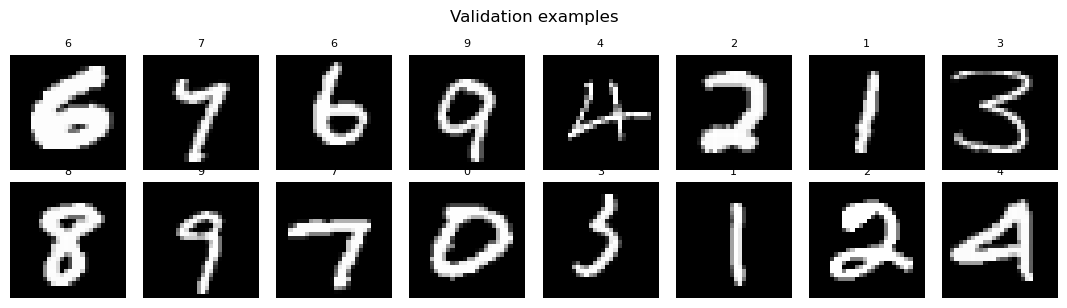

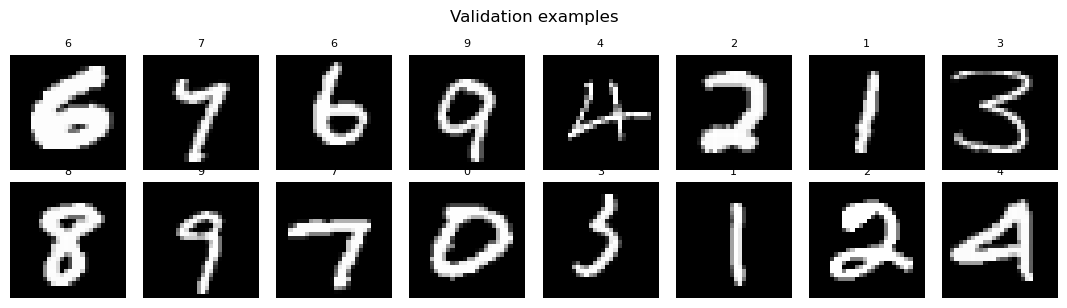

In [3]:
# DATASET은 앞의 설정 셀에서 지정합니다.train/valは公式trainから分割。
def vision_loaders(name, augment=False):
    cls = {'fashion':datasets.FashionMNIST, 'cifar':datasets.CIFAR10, 'mnist':datasets.MNIST}[name]
    base = [transforms.ToTensor()]
    if name=='cifar': base += [transforms.Normalize((.5,)*3, (.5,)*3)]
    eval_tf = transforms.Compose(base)
    train_tf = transforms.Compose(([transforms.RandomCrop(32,padding=4),
                                    transforms.RandomHorizontalFlip()] if augment else []) + base)
    train_ds = cls(DATA_ROOT, train=True, download=True, transform=train_tf)
    val_ds = cls(DATA_ROOT, train=True, download=True, transform=eval_tf)
    test_ds = cls(DATA_ROOT, train=False, download=True, transform=eval_tf)
    ids = torch.randperm(len(train_ds), generator=torch.Generator().manual_seed(SEED))
    n_val = 5000 if name=='cifar' else 6000
    train_ids = ids[n_val:][:TRAIN_N].tolist()
    val_ids = ids[:n_val][:VAL_N].tolist()
    test_ids = torch.randperm(len(test_ds), generator=torch.Generator().manual_seed(SEED+1))[:TEST_N].tolist()
    assert not (set(train_ids) & set(val_ids))
    train = DataLoader(Subset(train_ds,train_ids), batch_size=BATCH, shuffle=True,
                       generator=torch.Generator().manual_seed(SEED), num_workers=0)
    val = DataLoader(Subset(val_ds,val_ids), batch_size=BATCH, shuffle=False, num_workers=0)
    test = DataLoader(Subset(test_ds,test_ids), batch_size=BATCH, shuffle=False, num_workers=0)
    return train,val,test

train_loader, val_loader, test_loader = vision_loaders(DATASET)
xb,yb = next(iter(val_loader))
print('split sizes:', *(len(dl.dataset) for dl in [train_loader,val_loader,test_loader]))
print('shape:', xb.shape, 'dtype:', xb.dtype, 'range:', (xb.min().item(),xb.max().item()))
image_grid(xb[:16], yb[:16].tolist(), title='Validation examples', normalized=DATASET=='cifar')

## §3 · VAE와 ELBO 구현

decoder는 logits를 출력합니다. recon은 픽셀 합, KL은 latent 합, 최종 손실은 배치 평균입니다. 평가는 1-sample MC negative ELBO이며 그림의 μ 재구성과 구분합니다.

In [4]:
def reparameterize(mu,logvar):
    return mu + torch.exp(.5*logvar)*torch.randn_like(mu)

def gaussian_kl(mu,logvar):
    # shape [B,Z] 유지: 차원별 진단에 사용
    return .5*(mu.pow(2)+logvar.exp()-1-logvar)

class VAE(nn.Module):
    def __init__(self,zdim=2,conditional=False):
        super().__init__(); self.zdim=zdim; self.conditional=conditional
        cond=10 if conditional else 0
        self.encoder=nn.Sequential(nn.Linear(784+cond,256),nn.ReLU())
        self.mu_head=nn.Linear(256,zdim); self.lv_head=nn.Linear(256,zdim)
        self.decoder=nn.Sequential(nn.Linear(zdim+cond,256),nn.ReLU(),nn.Linear(256,784))
    def condition(self,y):
        return F.one_hot(y,num_classes=10).float()
    def encode(self,x,y=None):
        h=x.flatten(1)
        if self.conditional:
            assert y is not None; h=torch.cat([h,self.condition(y)],1)
        h=self.encoder(h)
        return self.mu_head(h),self.lv_head(h)
    def decode(self,z,y=None):
        if self.conditional:
            assert y is not None; z=torch.cat([z,self.condition(y)],1)
        return self.decoder(z).view(-1,1,28,28)
    def forward(self,x,y=None,sample=True):
        mu,lv=self.encode(x,y)
        z=reparameterize(mu,lv) if sample else mu
        return self.decode(z,y),mu,lv

def vae_terms(logits,x,mu,logvar):
    recon=F.binary_cross_entropy_with_logits(logits,x,reduction='none').flatten(1).sum(1)
    kl=gaussian_kl(mu,logvar).sum(1)
    return recon,kl

def vae_epoch(model,loader,optimizer=None,beta=1.0):
    training=optimizer is not None; model.train(training)
    total_r=total_k=count=0
    with torch.set_grad_enabled(training):
        for x,y in loader:
            x,y=x.to(DEVICE),y.to(DEVICE)
            if training: optimizer.zero_grad(set_to_none=True)
            logits,mu,lv=model(x,y,sample=True)
            recon,kl=vae_terms(logits,x,mu,lv); loss=(recon+beta*kl).mean()
            assert torch.isfinite(loss), 'Nonfinite VAE loss: inspect logvar and learning rate'
            if training: loss.backward(); optimizer.step()
            total_r+=recon.detach().sum().item(); total_k+=kl.detach().sum().item(); count+=len(x)
    r,k=total_r/count,total_k/count
    return dict(recon=r,kl=k,nelbo=r+k,objective=r+beta*k)

def eval_vae(model,loader):
    # 평가 난수를 고정하고 훈련 RNG 흐름은 복원. 1-sample MC estimate.
    was_training=model.training
    with torch.random.fork_rng(devices=list(range(torch.cuda.device_count()))):
        torch.manual_seed(12345)
        if torch.cuda.is_available(): torch.cuda.manual_seed_all(12345)
        result=vae_epoch(model,loader)
    model.train(was_training)
    return result

def fit_vae(beta=1.,zdim=2,conditional=False,epochs=EPOCHS,warmup=False):
    seed_all(); model=VAE(zdim,conditional).to(DEVICE)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)
    history=[]; best=float('inf'); state=None; start=time.perf_counter()
    # 매 조건 같은 shuffle 난수열에서 시작하도록 generator도 초기화
    train_loader.generator.manual_seed(SEED)
    for ep in range(epochs):
        effective=beta*min(1.,(ep+1)/max(1,epochs//2)) if warmup else beta
        tr=vae_epoch(model,train_loader,opt,effective); va=eval_vae(model,val_loader)
        history.append(dict(epoch=ep+1,beta=effective,train_recon=tr['recon'],train_kl=tr['kl'],
                            val_recon=va['recon'],val_kl=va['kl'],val_nelbo=va['nelbo']))
        # 각 beta의 훈련 목적에 맞춰 checkpoint 선택. 조건 간 공통 평가 척도는 R+K.
        selection=va['recon']+beta*va['kl']
        if selection<best: best=selection; state=cpu_state(model)
        print(f"epoch {ep+1} beta={effective:.2f}: recon={va['recon']:.2f} KL={va['kl']:.2f} NELBO={va['nelbo']:.2f}")
    model.load_state_dict(state); model.eval()
    return model,history,time.perf_counter()-start

def plot_vae(history):
    fig,axes=plt.subplots(1,3,figsize=(11,3))
    for ax,key in zip(axes,['recon','kl','nelbo']):
        ax.plot([r['epoch'] for r in history],[r['val_'+key] for r in history],label='validation')
        if key!='nelbo': ax.plot([r['epoch'] for r in history],[r['train_'+key] for r in history],label='train')
        ax.set_title(key); ax.set_xlabel('epoch'); ax.grid(alpha=.2); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

@torch.no_grad()
def recon_and_samples(model):
    model.eval(); x,y=next(iter(val_loader)); x,y=x[:8].to(DEVICE),y[:8].to(DEVICE)
    logits,mu,lv=model(x,y,sample=False)
    image_grid(torch.cat([x,logits.sigmoid()]),title='Top: input / Bottom: decode(mu)')
    seed_all(123); z=torch.randn(32,model.zdim,device=DEVICE)
    labels=torch.arange(32,device=DEVICE)%10
    image_grid(model.decode(z,labels).sigmoid(),title='Prior sample: displayed pixel probabilities')
    return mu

## A · 재매개화 / 15분

μ, logvar, 선택적 eps를 받아 z를 반환하세요. eps가 없으면 randn_like를 사용하고, 있을 때는 결정적인 값으로 검사 가능하게 하세요.

In [5]:
def my_reparam(mu,logvar,eps=None):
    # TODO
    return None

In [6]:
mu=torch.tensor([[2.,-1.]],requires_grad=True); lv=torch.full_like(mu,math.log(4.),requires_grad=True)
r=my_reparam(mu,lv,torch.ones_like(mu))
if r is None: print('미완성: A를 구현하세요.')
else:
    torch.testing.assert_close(r,torch.tensor([[4.,1.]]))
    r.sum().backward(); torch.testing.assert_close(mu.grad,torch.ones_like(mu))
    assert lv.grad is not None
    print('PASS A')

미완성: A를 구현하세요.


**기록:** 구현한 식 또는 shape, 검사 결과, 아직 불확실한 점을 적으세요.

_여기에 작성_

## B · 배치별 negative ELBO / 20분

logits,x,mu,logvar를 받아 loss scalar, recon [B], KL [B]를 반환하세요. β를 지원하고 픽셀·잠재 축은 합, 배치는 평균을 쓰세요.

In [7]:
def my_vae_loss(logits,x,mu,logvar,beta=1.):
    # TODO
    return None

In [8]:
logits=torch.zeros(2,1,2,2); x=torch.ones_like(logits); mu=torch.tensor([[1.,0.],[0.,0.]]); lv=torch.zeros_like(mu)
r=my_vae_loss(logits,x,mu,lv)
if r is None: print('미완성: B를 구현하세요.')
else:
    loss,recon,kl=r
    torch.testing.assert_close(recon,torch.full((2,),4*math.log(2)))
    torch.testing.assert_close(kl,torch.tensor([.5,0.]))
    assert abs(loss.item()-(4*math.log(2)+.25))<1e-5
    doubled=my_vae_loss(logits.repeat(2,1,1,1),x.repeat(2,1,1,1),mu.repeat(2,1),lv.repeat(2,1))[0]
    torch.testing.assert_close(loss,doubled)
    print('PASS B: reduction invariant to duplicated batch')

미완성: B를 구현하세요.


**기록:** 구현한 식 또는 shape, 검사 결과, 아직 불확실한 점을 적으세요.

_여기에 작성_

## C · latent 차원 비교 / 35–45분

zdim=2와 8을 β=1, 같은 예산으로 학습하고 recon·KL·nelbo를 보고하세요. 각 모델에서 prior 샘플을 그리세요.

In [9]:
def latent_experiment():
    # TODO
    return None

In [10]:
rows=latent_experiment()
if rows is None: print('미완성: C를 작성하세요.')
else:
    assert {r['zdim'] for r in rows}=={2,8}
    assert all(abs(r['nelbo']-r['recon']-r['kl'])<1e-4 for r in rows)
    display(rows)

미완성: C를 작성하세요.


**기록:** 구현한 식 또는 shape, 검사 결과, 아직 불확실한 점을 적으세요.

_여기에 작성_

## D · deterministic AE 비교 / 30–45분

VAE(zdim=2)를 μ만 사용하는 AE처럼 학습하세요. loss는 reconstruction만 사용합니다. AE식 재구성과 임의 prior 샘플을 시각화하세요. val reconstruction 수치를 반환하세요.

In [11]:
def ae_experiment():
    # TODO
    return None

In [12]:
r=ae_experiment()
if r is None: print('미완성: D는 도전 과제입니다.')
else:
    assert np.isfinite(r) and r>=0
    print('deterministic AE val reconstruction:',r)

미완성: D는 도전 과제입니다.


**기록:** 구현한 식 또는 shape, 검사 결과, 아직 불확실한 점을 적으세요.

_여기에 작성_

## 비교 실험 해석 · 5문장 필수 틀

1. 나의 질문과 바꾼 변수는 …
2. 고정한 조건(분할, seed, 예산, 평가)은 …
3. 실제 관측 결과는 … (숫자·그림 번호를 근거로)
4. 이 결과만으로 말할 수 없는 것은 …
5. 다음에 한 가지만 더 검증한다면 …

| 조건 | seed | 학습 예산 | params | validation 지표 | 시간 | 관찰 |
|---|---|---|---|---|---|---|
| 기준 | | | | | | |
| 변경 | | | | | | |

### 자기 점검 기준 (100점 환산, 성적 부여 목적 아님)
- 구현의 shape·수식·gradient·mask 계약 30
- 통제 조건과 재현 가능한 코드 25
- 실제 결과 표·그림과 실패 사례 25
- 과장 없는 해석과 한계·후속 실험 20

고정 정확도나 생성 품질 기준은 없습니다. 개선되지 않은 실험도 근거를 잘 남기면 좋은 결과물입니다.